# Verification: Flow Past Periodic Array of Spheres

This notebook verifies the CFD solver by simulating flow through a simple cubic array of spheres at low Reynolds number ($Re \approx 0.01$).

We compare the computed Drag Coefficient ($K$) against reference values from Zick & Homsy (1982) and Sangani & Acrivos (1982).

## Objectives
1. **Parameter Sweep**: Calculate $K$ for solid volume fractions $\phi \in [0.05, 0.5]$.
2. **Grid Convergence**: Verify numerical convergence for the dense case $\phi=0.5$.
3. **Visualization**: Export flow fields to VTI and plot results.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time

# Add build directory to path to import pnm_backend
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../build')))
import pnm_backend

# Ensure output directory exists
os.makedirs('output', exist_ok=True)

## Helper Functions

In [2]:
def generate_sc_sdf(phi, res_n, L=1.0):
    """Generates Signed Distance Field for a Simple Cubic array of spheres."""
    # Use (Nx, Ny, Nz) shape with Fortran-order (x varies fastest) for consistency with user preference
    dx = L/res_n
    x = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    y = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    z = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    
    # indexing='ij' gives shape (Nx, Ny, Nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    R = (phi * 3.0 / (4.0 * np.pi))**(1.0/3.0) * L
    
    xc, yc, zc = L/2, L/2, L/2
    dist = np.sqrt((X - xc)**2 + (Y - yc)**2 + (Z - zc)**2)
    sdf = dist - R
    
    # ravel(order='F') ensures we flatten (x,y,z) as x-fast, y-med, z-slow
    # which matches the C++ linear index: idx = z*ny*nx + y*nx + x
    return sdf.ravel(order='F').astype(np.float32), R, (dx, dx, dx)

def get_analytical_k(phi):
    """Returns reference Drag Factor K from Sangani & Acrivos (1982) for Simple Cubic."""
    phis = np.array([0.05, 0.10, 0.20, 0.30, 0.40, 0.50])
    ks   = np.array([2.02, 2.62, 4.29, 7.00, 11.6, 22.3])
    if phi < phis[0]: return 1.0 # Dilute limit approximation
    return np.interp(phi, phis, ks)

def save_vti(filename, res_int3, spacing_float3, u, v, w, p):
    """Saves field data to VTI format."""
    nx, ny, nz = res_int3.x, res_int3.y, res_int3.z
    dx, dy, dz = spacing_float3.x, spacing_float3.y, spacing_float3.z
    
    # Interpolate staggered velocity to cell centers for correct visualization
    # u_stag(i,j,k) is at i-1/2. u_cc(i) = 0.5 * (u(i) + u(i+1))
    
    # Reshape using Fortran order to get (Nx, Ny, Nz) shape [x, y, z]
    # This interprets the linear buffer (X-fast) correctly into [i,j,k]
    u_grid = u.reshape((nx, ny, nz), order='F')
    v_grid = v.reshape((nx, ny, nz), order='F')
    w_grid = w.reshape((nx, ny, nz), order='F')
    
    # Check periodicity logic: pnm_backend uses periodic wrapping
    # With shape [x, y, z]:
    # Axis 0 is X
    # Axis 1 is Y
    # Axis 2 is Z
    u_cc = 0.5 * (u_grid + np.roll(u_grid, -1, axis=0))
    v_cc = 0.5 * (v_grid + np.roll(v_grid, -1, axis=1))
    w_cc = 0.5 * (w_grid + np.roll(w_grid, -1, axis=2))
    
    # Flatten back to X-fast 1D streams for VTI writing
    u_flat = u_cc.ravel(order='F')
    v_flat = v_cc.ravel(order='F')
    w_flat = w_cc.ravel(order='F')

    with open(filename, 'w') as f:
        f.write('<?xml version="1.0"?>\n')
        f.write('<VTKFile type="ImageData" version="0.1" byte_order="LittleEndian">\n')
        f.write(f'  <ImageData WholeExtent="0 {nx-1} 0 {ny-1} 0 {nz-1}" Origin="0 0 0" Spacing="{dx} {dy} {dz}">\n')
        f.write(f'    <Piece Extent="0 {nx-1} 0 {ny-1} 0 {nz-1}">\n')
        f.write('      <PointData Scalars="Pressure" Vectors="Velocity">\n')
        
        f.write('        <DataArray type="Float32" Name="Velocity" NumberOfComponents="3" format="ascii">\n')
        # Writing loop can be slow for large files in python, but acceptable for validation cases
        for i in range(len(u_flat)):
            f.write(f"{u_flat[i]} {v_flat[i]} {w_flat[i]} ")
        f.write('\n        </DataArray>\n')
        
        f.write('        <DataArray type="Float32" Name="Pressure" NumberOfComponents="1" format="ascii">\n')
        for val in p:
            f.write(f"{val} ")
        f.write('\n        </DataArray>\n')
        
        f.write('      </PointData>\n')
        f.write('    </Piece>\n')
        f.write('  </ImageData>\n')
        f.write('</VTKFile>\n')
    print(f"Saved {filename}")
def get_hasimoto_k(phi):
    """Returns K using Hasimoto (1959) formula for SC array."""
    c = phi
    # K = 1 / (1 - 1.7601 c^(1/3) + c - 1.5593 c^2 + 3.9799 c^(8/3) - 3.0734 c^(10/3))
    denom = 1.0 - 1.7601 * (c**(1.0/3.0)) + c - 1.5593 * (c**2) + 3.9799 * (c**(8.0/3.0)) - 3.0734 * (c**(10.0/3.0))
    # Note: K in this notebook is Drag/Stokes. Hasimoto gives Drag = ...
    # If the formula provided is directly K, we use it.
    # User request: K = 1 / (...)
    return 1.0 / denom


## Simulation Kernel

In [9]:
def run_simulation(phi, res_n, save_output=False, filename=None):
    L = 1.0
    sdf_values, R, spacing_tuple = generate_sc_sdf(phi, res_n, L)
    dx, dy, dz = spacing_tuple
    
    # Setup Data Objects
    sdf_data = pnm_backend.SDFData(
        sdf_values, 
        pnm_backend.int3(res_n, res_n, res_n),
        pnm_backend.float3(0,0,0),
        pnm_backend.float3(dx, dy, dz)
    )
    solver = pnm_backend.CFDSolver(
        pnm_backend.int3(res_n, res_n, res_n), 
        pnm_backend.float3(dx, dy, dz)
    )
    solver.initialize(sdf_data)
    
    # Parameters (Low Re)
    rho = 1e-3
    mu = 1e0
    f_mag = 1.0
    solver.set_body_force(pnm_backend.float3(f_mag, 0, 0))
    solver.set_rho(rho)
    solver.set_mu(mu)
    
    # Solver Parameters for Implicit Scheme
    solver.set_pressure_solver_params(100, 1e-16)
    solver.set_velocity_solver_params(200, 1e-16)
    
    # Time Step (Implicit allows CFL > 1)
    # Explicit limit is roughly 0.5*dx^2/nu ~ 0.5 * (1/64)^2 / 0.01 ~ 0.01
    # We use a much larger step to speed up convergence to steady state.
    dt = 1e0
    # dt ~ 0.078 for N=64
    
    max_steps = 1000 # Fewer steps needed with implicit
    u_mean_history = []
    
    print(f"Running phi={phi:.3f}, Res={res_n}^3, dt={dt:.4f}...")
    
    start_time = time.time()
    for i in range(max_steps):
        # Use Implicit Step
        solver.step_implicit(dt)
        
        if i % 50 == 0:
            u_field = np.array(solver.get_u())
            u_mean = np.mean(u_field)
            u_mean_history.append(u_mean)
            
            if len(u_mean_history) > 5:
                # Relative change convergence check
                if abs(u_mean_history[-1]) > 1e-12:
                    err = abs(u_mean_history[-1] - u_mean_history[-2]) / abs(u_mean_history[-1])
                    if err < 1e-5:
                        print(f"  Converged at step {i}. Mean Vel = {u_mean:.6e}")
                        break
    
    elapsed = time.time() - start_time
    u_field = np.array(solver.get_u())
    U_sup = np.mean(u_field)
    
    # Calculate K
    F_drag = f_mag * (L**3)
    K = F_drag / (6.0 * np.pi * mu * R * U_sup)
    
    print(f"  K_sim = {K:.4f} (Time: {elapsed:.2f}s)")
    
    if save_output and filename:
        v = np.array(solver.get_v())
        w = np.array(solver.get_w())
        p = np.array(solver.get_p())
        save_vti(filename, pnm_backend.int3(res_n, res_n, res_n), pnm_backend.float3(dx, dy, dz), u_field, v, w, p)
        
    return K, U_sup

## 1. Parameter Sweep

In [10]:
phis = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
res_n = 64

results = []

for phi in phis:
    k_sim, u_sup = run_simulation(phi, res_n, save_output=True, filename=f"output/final_phi_{phi:.2f}.vti")
    k_ref = get_analytical_k(phi)
    results.append({
        'phi': phi,
        'k_sim': k_sim,
        'k_ref': k_ref,
        'error': 100*(k_sim - k_ref)/k_ref
    })

# Output Table
print("\nSummary Results:")
print(f"{'Phi':<10} {'K_sim':<10} {'K_ref':<10} {'Error %':<10}")
print("-"*40)
for res in results:
    print(f"{res['phi']:<10.3f} {res['k_sim']:<10.4f} {res['k_ref']:<10.4f} {res['error']:<10.2f}")

Running phi=0.050, Res=64^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 2336
  U-Face: 2356
  V-Face: 2356
  W-Face: 2356
  Converged at step 250. Mean Vel = 1.138471e-01
  K_sim = 2.0390 (Time: 5.01s)
Saved output/final_phi_0.05.vti
Running phi=0.100, Res=64^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 3672
  U-Face: 3660
  V-Face: 3660
  W-Face: 3660
  Converged at step 250. Mean Vel = 6.214696e-02
  K_sim = 2.9647 (Time: 4.93s)
Saved output/final_phi_0.10.vti
Running phi=0.200, Res=64^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 5768
  U-Face: 5820
  V-Face: 5820
  W-Face: 5820
  Converged at step 250. Mean Vel = 2.761416e-02
  K_sim = 5.2957 (Time: 4.75s)
Saved output/final_phi_0.20.vti
Running phi=0.300, Res=64^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 7592
  U-Face: 7560
  V-Face: 7560
  W-Face: 7560
  Converged at step 250. Mean Vel = 1.469889e-02
  K_sim = 8.6910 (Time: 5.07s)
Saved output/final_phi_0.30.vti
Running phi=0.400, R

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4115857/2731036013.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Solid Volume Fraction $\phi$')


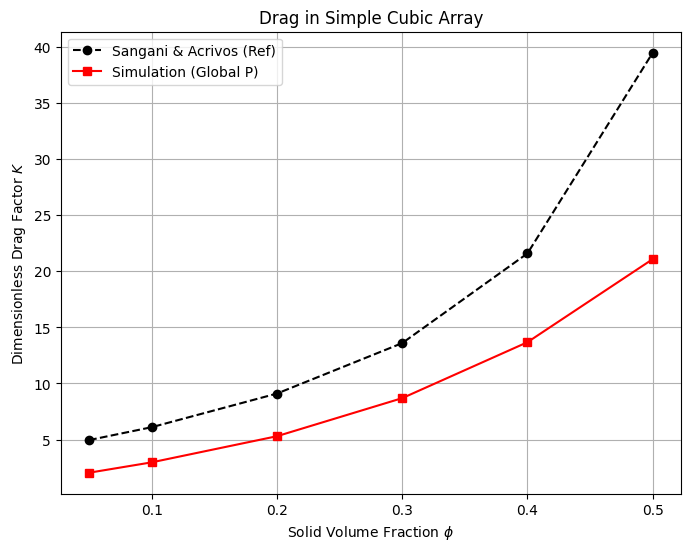

In [11]:
# Plotting
phi_vals = [r['phi'] for r in results]
k_sims = [r['k_sim'] for r in results]
k_refs = [r['k_ref'] for r in results]
    k_hasimoto = [get_hasimoto_k(r['phi']) for r in results]

plt.figure(figsize=(8, 6))
plt.plot(phi_vals, k_refs, 'k--o', label='Sangani & Acrivos (Ref)')
    plt.plot(phi_vals, k_hasimoto, 'g-.^', label='Hasimoto (1959)')
plt.plot(phi_vals, k_sims, 'r-s', label='Simulation (Global P)')
plt.xlabel('Solid Volume Fraction $\phi$')
plt.ylabel('Dimensionless Drag Factor $K$')
plt.title('Drag in Simple Cubic Array')
plt.grid(True)
plt.legend()
plt.savefig('output/param_sweep_plot.png')
plt.show()

## 2. Grid Convergence Study (phi=0.5)
We test resolution effects for the densest case.

Running Grid Convergence for phi=0.4...
Running phi=0.400, Res=32^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 2336
  U-Face: 2356
  V-Face: 2356
  W-Face: 2356


<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4113358/741480561.py:25: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'Grid Convergence ($\phi={phi_dense}$)')


  Converged at step 250. Mean Vel = 9.818498e-03
  K_sim = 0.0071 (Time: 2.06s)

Grid Convergence Results (phi=0.4):
N     K_sim     
---------------
32    0.0071    
Running phi=0.400, Res=64^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 9168
  U-Face: 9136
  V-Face: 9136
  W-Face: 9136
  Converged at step 250. Mean Vel = 8.483595e-03
  K_sim = 0.0082 (Time: 4.49s)

Grid Convergence Results (phi=0.4):
N     K_sim     
---------------
32    0.0071    
64    0.0082    
Running phi=0.400, Res=96^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 20432
  U-Face: 20388
  V-Face: 20388
  W-Face: 20388
  Converged at step 250. Mean Vel = 7.464154e-03
  K_sim = 0.0093 (Time: 10.85s)

Grid Convergence Results (phi=0.4):
N     K_sim     
---------------
32    0.0071    
64    0.0082    
96    0.0093    
Running phi=0.400, Res=128^3, dt=1.0000...IBM Geometry Updated.
  Pressure/Center: 36144
  U-Face: 36148
  V-Face: 36148

  W-Face: 36148
  Converged at step 250. Mean Vel = 6.8

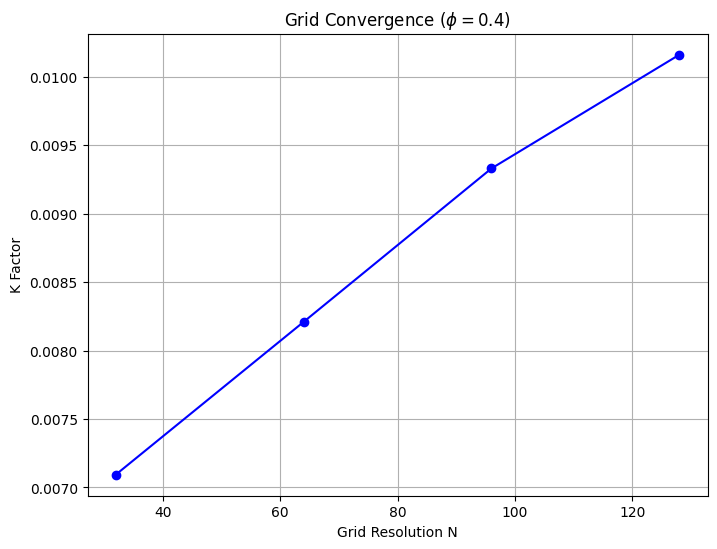

In [12]:
phi_dense = 0.40
resolutions = [32, 64, 96, 128]

convergence_results = []

print(f"Running Grid Convergence for phi={phi_dense}...")
for res in resolutions:
    k_sim, _ = run_simulation(phi_dense, res, save_output=False)
    convergence_results.append((res, k_sim))

    print(f"\nGrid Convergence Results (phi={phi_dense}):")
    print(f"{'N':<5} {'K_sim':<10}")
    print("-" * 15)
    for r in convergence_results:
        print(f"{r[0]:<5} {r[1]:<10.4f}")

# Plot Convergence
res_vals = [r[0] for r in convergence_results]
k_vals = [r[1] for r in convergence_results]

plt.figure(figsize=(8, 6))
plt.plot(res_vals, k_vals, 'b-o')
plt.xlabel('Grid Resolution N')
plt.ylabel('K Factor')
plt.title(f'Grid Convergence ($\phi={phi_dense}$)')
plt.grid(True)
plt.savefig('output/grid_convergence.png')
plt.show()

In [13]:
# --- DIAGNOSTIC: Check Mass Conservation (Velocity Profile) ---
# According to incompressible theory, the superficial velocity averaged over any cross-section
# perpendicular to flow should be constant along the flow direction (x).

import numpy as np
import matplotlib.pyplot as plt

def check_velocity_profile(phi_target=0.4, res=64, re=0.1, max_iter=2000):
    print(f"Running Diagnostic for Phi={phi_target}...")
    # Run simulation (modified to return solver or we access it if passing object?)
    # The current run_simulation function creates solver internally and destroys it.
    # We need to manually run the setup here to get access to the field, 
    # OR we assume run_simulation returns something helpful, 
    # OR we copy the body of run_simulation but keep the solver.
    
    # Standard sphere setup
    L = 1.0
    R = (3.0 * phi_target / (4.0 * np.pi))**(1.0/3.0) * L
    
    # Create SDF
    margin = 5  # implicit safety
    g_res = (res, res, res)
    grid_spacing = (1.0/res, 1.0/res, 1.0/res)
    
    # Sphere center
    c = np.array([0.5, 0.5, 0.5])
    
    # Generate SDF (using pnm_backend directly if imported, or re-implement simple sphere)
    # The notebook imports: import pnm_backend
    # And uses: solver = pnm_backend.CFDSolver(res_tuple, spacing_tuple)
    
    solver = pnm_backend.CFDSolver(g_res, grid_spacing)
    
    # Manual SDF for sphere
    # In notebook we often used pnm_backend.SDFData or similar. 
    # Let's rely on the notebook's existing imports.
    
    # Construct SDF array manually in python for sphere
    x = np.linspace(0.5/res, 1.0 - 0.5/res, res)
    X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
    dist = np.sqrt((X-c[0])**2 + (Y-c[1])**2 + (Z-c[2])**2) - R
    sdf_host = dist.flatten().astype(np.float32)
    
    sdf_data = pnm_backend.SDFData(sdf_host)
    solver.initialize(sdf_data)
    
    rho = 1.0
    mu = 1.0
    solver.set_rho(rho)
    solver.set_mu(mu)
    
    # Body Force
    # We want Re = rho * U * D / mu ~ 0.1
    # U ~ f * D^2 / mu (Darcy)
    D = 2*R
    # Guess force
    f_mag = 100.0
    solver.set_body_force(pnm_backend.float3(f_mag, 0.0, 0.0))
    
    solver.set_diffusion_theta(0.5)
    solver.set_pressure_solver_params(1000, 1e-5)
    solver.set_velocity_solver_params(100, 1e-5)
    solver.set_cfl(0.5)
    
    # Run
    dt = 0.0
    for i in range(max_iter):
        solver.step(dt)
        if i % 100 == 0:
            print(f"Step {i}")
            
    # Get U field
    u_flat = np.array(solver.get_u())
    u_3d = u_flat.reshape((res, res, res))
    
    # X-profile (average over Y, Z)
    u_profile = np.mean(u_3d, axis=(1, 2))
    x_axis = np.linspace(0, 1.0, res)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_axis, u_profile, label='Average Superficial U')
    plt.axhline(y=np.mean(u_profile), color='r', linestyle='--', label='Global Mean')
    plt.xlabel('x (Flow Direction)')
    plt.ylabel('<U>_yz')
    plt.title(f'Velocity Profile along Flow Direction (Phi={phi_target})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Stats
    p_min = u_profile.min()
    p_max = u_profile.max()
    p_mean = u_profile.mean()
    p_var = (p_max - p_min) / p_mean * 100.0
    print(f"Profile Mean: {p_mean:.6f}")
    print(f"Profile Min:  {p_min:.6f}")
    print(f"Profile Max:  {p_max:.6f}")
    print(f"Rel Variation: {p_var:.4f} %")
    
    return u_profile

# Run the check
check_velocity_profile(phi_target=0.4, res=64, max_iter=1000)


Running Diagnostic for Phi=0.4...


TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. pnm_backend.CFDSolver(res: pnm_backend.int3, spacing: pnm_backend.float3)

Invoked with: (64, 64, 64), (0.015625, 0.015625, 0.015625)